## Random forest classifier model

*The hail_v4.csv (manually verified reports, radar features) file needs to be uploaded to the current working directory. The version used by the authors can be obtained from the OneDrive in the availability statement, or a user may upload their own file obtained by following the verification process in the manual_verification.ipynb notebook.*

This notebook first examines the calculated features to show how a simpler clustering approach is not suitable, then trains a random forest classifier model based on the reports' associated radar features. This is the core of our work on the machine learning side of the project.

In [1]:
# Necessary imports below
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import random
import pandas as pd

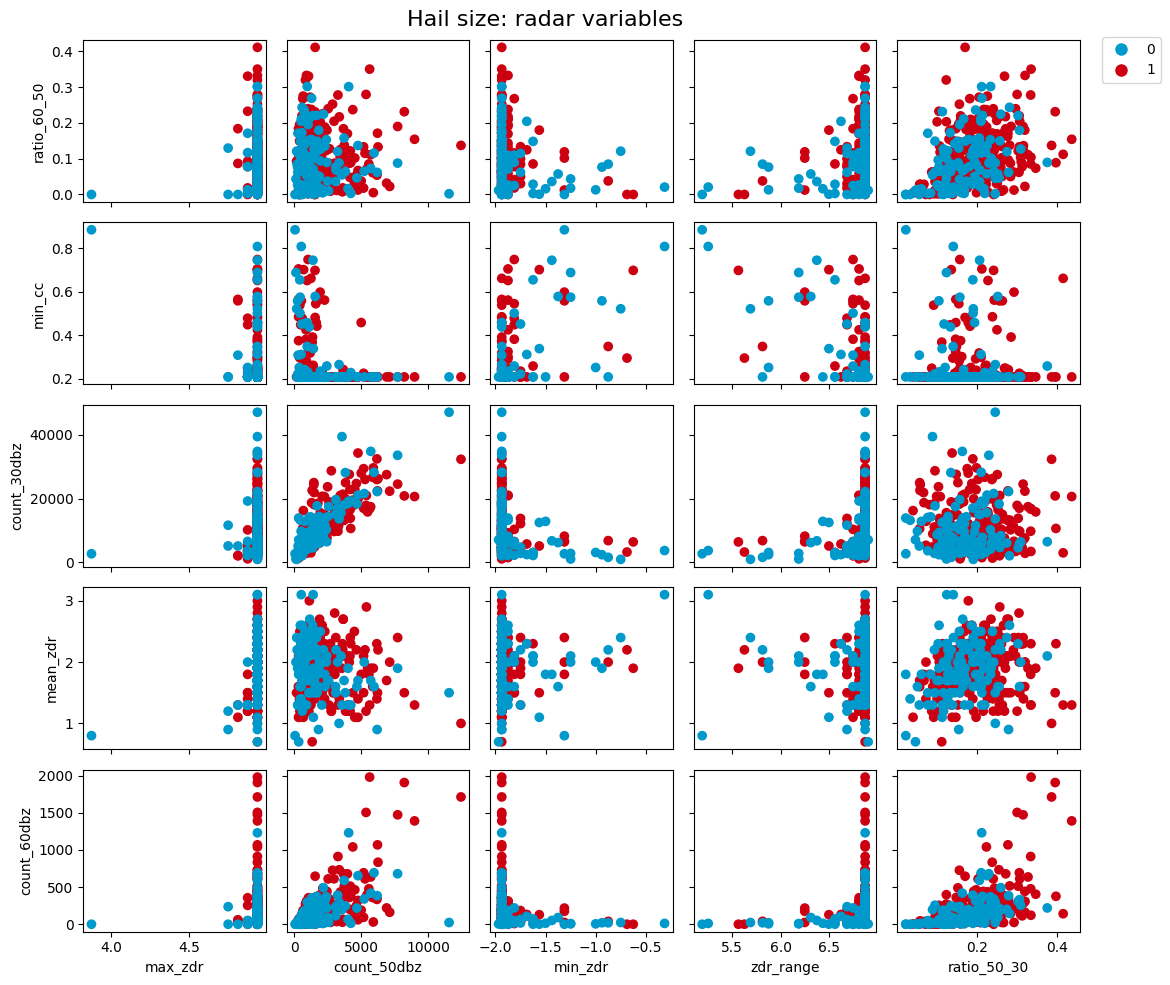

In [3]:
# Before training, investigate features. If desired, this code can be run multiple times to view different combinations of features.
hail_data = pd.read_csv('hail_v4.csv')

# Define rows and columns of our display, each row/col is one variable to be examined with others
# I am shuffling the list and running the code repeatedly to examine more combinations
feature_list = ['max_dbz',
       'mean_dbz', 'max_zdr', 'mean_zdr', 'min_zdr', 'mean_cc', 'min_cc',
       'count_30dbz', 'count_50dbz', 'count_60dbz', 'ratio_50_30', 'ratio_60_50', 'zdr_range']
random.shuffle(feature_list)
rows = feature_list[:5]
cols = feature_list[5:10]

# Create new column of colors corresponding to the labeled storm morphology
colors = []
# Dictionary to make life easier
map = {0:'#09c', 1:'#c01'}
for m in hail_data['sig']:
  colors.append(map[m])
hail_data['colors'] = colors

# Create the subplots
fig, axes = plt.subplots(5, 5, figsize=(11,10))
for i_row in range(5):
  for i_col in range(5):
    a = axes[i_row, i_col]
    # Fill in each plot, coloring points based on their labeled morphology
    a.scatter(hail_data[cols[i_col]], hail_data[rows[i_row]], color=hail_data['colors'])
    # Label axes only on the outside of the figure
    a.set_xlabel(cols[i_col])
    a.set_ylabel(rows[i_row])
    a.label_outer()

# Creating legend for the colors
elements = []
for l in map.keys():
  c = map[l]
  # I used the bottom example on MatPlotLib docs for help with this solution
  # https://matplotlib.org/stable/gallery/text_labels_and_annotations/custom_legends.html
  elements.append(Line2D([0], [0], marker='o', color='#fff', markerfacecolor=c, label=l, markersize=10))

fig.legend(handles=elements, loc='upper left', bbox_to_anchor=(1,0.96))
fig.suptitle('Hail size: radar variables', fontsize=16)
plt.tight_layout()
plt.show()

# When done plotting, remove the colors column to avoid messing with future dataframe operations
hail_data = hail_data.drop('colors', axis=1)

### Split the dataset into training, validation and testing subsets

In [4]:
# Split the dataset into training and testing data.
display(hail_data['yr'].value_counts())
hail_data = pd.read_csv('hail_v4.csv')
hail_data = hail_data.drop(['Unnamed: 0', 'mo', 'dy', 'slat', 'slon', 'radar_dist', 'date', 'time', 'radar', 'datetime'], axis=1)

# Separating these temporally, the testing data will be the final years (2019-2020) and everything else will be used for training.
# Inside the training data, we can use 2017-2018 for validation, like an initial test with which we can adjust the model.
hail_train = hail_data[hail_data['yr'] <= 2016]
hail_val = hail_data[(hail_data['yr'] == 2017) | (hail_data['yr'] == 2018)]
hail_test = hail_data[(hail_data['yr'] == 2019) | (hail_data['yr'] == 2020)]
print(f'\nSample counts:\nTraining: {len(hail_train)}\t Validation: {len(hail_val)}\t Testing: {len(hail_test)}')

# Comparing the validation/testing data to the training dataset:
print('\n\n--- TRAINING:')
display(hail_train.drop(['yr'], axis=1).describe().drop(['count', '25%', '50%', '75%'], axis=0))
print('\n\n--- VALIDATION:')
display(hail_val.drop(['yr'], axis=1).describe().drop(['count', '25%', '50%', '75%'], axis=0))
print('\n\n--- TESTING:')
display(hail_test.drop(['yr'], axis=1).describe().drop(['count', '25%', '50%', '75%'], axis=0))

,count
yr,
2016,54
2014,50
2015,49
2019,46
2020,45
2018,43
2017,40
2013,33
2012,21



Sample counts:
Training: 209	 Validation: 83	 Testing: 91


--- TRAINING:


,mag,max_dbz,mean_dbz,max_zdr,mean_zdr,min_zdr,mean_cc,min_cc,count_30dbz,count_50dbz,count_60dbz,ratio_50_30,ratio_60_50,zdr_range,sig
mean,2.397990,67.370813,42.069856,4.928230,1.890431,-1.877691,0.965359,0.257871,10048.985646,2036.277512,213.760766,0.196957,0.103901,6.805921,0.665072
std,1.041801,3.465151,1.789687,0.075609,0.404665,0.180904,0.015535,0.126015,7481.815467,1917.898800,297.977042,0.070889,0.075310,0.209438,0.473099
min,1.000000,55.000000,37.100000,3.875000,0.800000,-1.937500,0.900000,0.208333,985.000000,67.000000,0.000000,0.024479,0.000000,5.187500,0.000000
max,4.750000,75.500000,47.300000,4.937500,2.700000,-0.625000,0.990000,0.885000,47079.000000,12473.000000,1979.000000,0.435525,0.350576,6.875000,1.000000




--- VALIDATION:


,mag,max_dbz,mean_dbz,max_zdr,mean_zdr,min_zdr,mean_cc,min_cc,count_30dbz,count_50dbz,count_60dbz,ratio_50_30,ratio_60_50,zdr_range,sig
mean,2.301325,67.722892,41.804819,4.935994,1.926506,-1.891566,0.958675,0.241667,10474.638554,1850.795181,170.445783,0.182351,0.099722,6.827560,0.710843
std,0.920524,3.959592,1.541768,0.009643,0.441473,0.223880,0.020823,0.101878,7506.921820,1450.148451,174.747431,0.065747,0.083626,0.223775,0.456127
min,1.000000,59.000000,38.500000,4.875000,0.700000,-1.937500,0.900000,0.208333,1093.000000,137.000000,0.000000,0.024334,0.000000,5.250000,0.000000
max,4.250000,78.500000,45.200000,4.937500,3.100000,-0.312500,0.990000,0.808333,39437.000000,7143.000000,733.000000,0.319903,0.411465,6.875000,1.000000




--- TESTING:


,mag,max_dbz,mean_dbz,max_zdr,mean_zdr,min_zdr,mean_cc,min_cc,count_30dbz,count_50dbz,count_60dbz,ratio_50_30,ratio_60_50,zdr_range,sig
mean,2.465824,68.307692,41.880220,4.932005,1.947253,-1.880151,0.962967,0.233095,11319.318681,2049.043956,194.813187,0.185109,0.092016,6.812157,0.725275
std,0.984481,4.024073,1.722738,0.028940,0.388256,0.208087,0.019916,0.079256,6974.373686,1512.769975,235.785209,0.070277,0.068666,0.212075,0.448849
min,1.000000,58.000000,37.100000,4.750000,0.700000,-1.968750,0.860000,0.208333,1383.000000,273.000000,0.000000,0.048315,0.000000,5.625000,0.000000
max,5.330000,77.500000,46.100000,4.937500,3.000000,-0.687500,0.990000,0.661667,29645.000000,7738.000000,1472.000000,0.414328,0.275148,6.906250,1.000000


### Ensuring the samples are representative:

Comparing the training dataset with the testing and validation, we see a similar mean `mag` (hail size) in all three, hovering around 2.2-2.6, with a standard deviation of about 1. Also, looking briefly at the variables, the means are generally similar between the different datasets, with the real exceptions being the 30dbz and 50dbz counts which appear to generally be larger in the 2020 (testing) dataset. Our three datasets are completely separate from one another and appear to be representative of the population.

### Training the model

Accuracy 0.73	Precision 0.68	Recall 0.73
F1 0.68


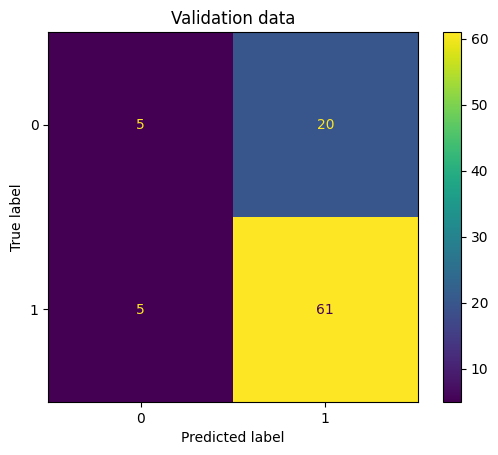

In [5]:
# These are the columns the model can use in prediction
cols = hail_data.drop(['mag', 'yr', 'sig'],axis=1).columns.to_list()
# print(cols)

x_train = hail_train[cols].to_numpy()
y_train = hail_train['sig'].to_numpy()

x_val = hail_val[cols].to_numpy()
y_val = hail_val['sig'].to_numpy()

x_test = hail_test[cols].to_numpy()
y_test = hail_test['sig'].to_numpy()

# Create random forest classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
forest = RandomForestClassifier(max_depth=2, random_state=0).fit(X=x_train, y=y_train)

# Evaluate predictions from default state
predictions = forest.predict(x_test)

sklearn_acc = accuracy_score(y_test, predictions)
sklearn_pre = precision_score(y_test, predictions, average='weighted')
sklearn_rec = recall_score(y_test, predictions, average='weighted')
sklearn_f1 = f1_score(y_test, predictions, average='weighted')

print(f"Accuracy {sklearn_acc:.2f}\tPrecision {sklearn_pre:.2f}\tRecall {sklearn_rec:.2f}\nF1 {sklearn_f1:.2f}")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, predictions)

# Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Validation data")

plt.show()

### Improving the model

Testing different configurations of hyperparameters to find the most skillful random forest.

In [6]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Further fine-tuning to find the best random forest we can
# Hyperparameters to test
depths = [3, 5, 7, 10]
n_estimators = [50, 100, 200]
minleaves = [1, 2, 5]
max_features_opts = ['sqrt', 'log2']

model_test = pd.DataFrame(columns=['f1_score', 'accuracy', 'precision', 'recall', 'max_depth', 'n_estimators', 'min_samples_leaf', 'max_features'])
# Loop through all combinations of these parameters
for depth in depths:
  for n_est in n_estimators:
    for minleaf in minleaves:
      for max in max_features_opts:
          # Create a random forest
          rf = RandomForestClassifier(n_estimators=n_est, max_depth=depth, min_samples_leaf=minleaf, max_features=max, class_weight='balanced', random_state=0).fit(x_train, y_train)

          # Predict and evaluate
          prediction = rf.predict(x_val)
          f1 = f1_score(y_val, prediction, average='weighted')
          ac = accuracy_score(y_val, prediction)
          pr = precision_score(y_val, prediction, average='weighted', zero_division=np.nan)
          re = recall_score(y_val, prediction, average='weighted')
          model_test.loc[len(model_test)] = [f1, ac, pr, re, depth, n_est, minleaf, max]

# Print out the top values by f-score
model_test = model_test.sort_values(by='f1_score', ascending=False)
display(model_test.iloc[:5])

,f1_score,accuracy,precision,recall,max_depth,n_estimators,min_samples_leaf,max_features
67,0.710417,0.734940,0.711242,0.734940,10,200,1,log2
66,0.710417,0.734940,0.711242,0.734940,10,200,1,sqrt
3,0.702440,0.710843,0.697456,0.710843,3,50,2,log2
2,0.702440,0.710843,0.697456,0.710843,3,50,2,sqrt
9,0.702440,0.710843,0.697456,0.710843,3,100,2,log2


### Evaluating the model

Now using the testing subset, we can give the model its "final exam" and evaluate its ability to predict hail size from radar features alone.

Accuracy 0.73	Precision 0.69	Recall 0.73
F1 0.70


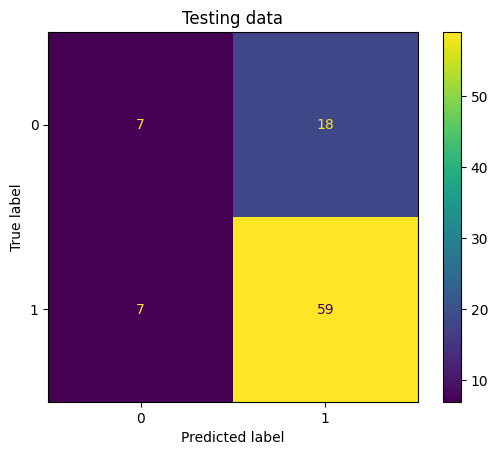

In [7]:
from sklearn.metrics import confusion_matrix
# Picking the best-performing model
rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=1, max_features='log2', class_weight='balanced', random_state=0).fit(x_train, y_train)
# Final test run!
prediction = rf.predict(x_test)

ac = accuracy_score(y_test, prediction)
pr = precision_score(y_test, prediction, average='weighted', zero_division=np.nan)
re = recall_score(y_test, prediction, average='weighted')
f1 = f1_score(y_test, prediction, average='weighted')

# Make a better plot of this later
print(f"Accuracy {ac:.2f}\tPrecision {pr:.2f}\tRecall {re:.2f}\nF1 {f1:.2f}")

# Create confusion matrix
cm = confusion_matrix(y_test, prediction)

# Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Testing data")

plt.show()